# Passo 1 - Exploração de Dados (EDA)

Este notebook tem como objetivo realizar a exploração inicial dos dados (EDA - Exploratory Data Analysis) a partir de um dataset público de atividades diárias do Fitbit.

Como não há dados reais disponíveis do aplicativo WellMe, este dataset será utilizado como base de referência para simular o comportamento dos usuários e exemplificar o caso de uso proposto neste projeto.

O WellMe é uma aplicação voltada à promoção de hábitos saudáveis por meio de gamificação, incentivando os usuários a realizarem atividades relacionadas à saúde, como exercícios físicos, sono adequado e rotina ativa.

O problema abordado neste projeto consiste em prever o nível de engajamento dos usuários com base em seus dados de uso. Dessa forma, nesta etapa inicial, busca-se compreender a estrutura do dataset, analisar as variáveis disponíveis, verificar a presença de valores nulos e identificar padrões que possam contribuir para o desenvolvimento de um modelo de Inteligência Artificial no contexto do WellMe.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../data/raw/fitbit_daily_activity.csv')

df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

### Estrutura do Dataset

A partir da função `info()`, observa-se que o dataset possui 457 registros e 15 colunas, representando informações relacionadas às atividades diárias dos usuários.

Todas as colunas apresentam 457 valores não nulos, indicando que não há presença de dados ausentes (missing values) neste conjunto de dados. Isso é um ponto positivo, pois reduz a necessidade de tratamento de dados na etapa de pré-processamento.

Em relação aos tipos de dados, a maioria das variáveis é do tipo numérico (`int64` e `float64`), o que é adequado para a aplicação de modelos de Machine Learning. A única variável do tipo `object` é a coluna `ActivityDate`, que representa a data das atividades.

As variáveis disponíveis incluem informações como número total de passos (`TotalSteps`), distâncias percorridas em diferentes níveis de atividade, minutos ativos (`VeryActiveMinutes`, `LightlyActiveMinutes`, etc.), tempo sedentário (`SedentaryMinutes`) e calorias gastas (`Calories`).

Essas informações são relevantes para o contexto do projeto WellMe, pois refletem diretamente o comportamento dos usuários em relação à prática de hábitos saudáveis, podendo ser utilizadas posteriormente para a construção de um modelo de previsão de engajamento.

In [5]:
df.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,4.570000e+02,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,4.628595e+09,6546.562363,4.663523,4.609847,0.179427,1.180897,0.478643,2.890197,0.001904,16.623632,13.070022,170.070022,995.282276,2189.452954
std,2.293781e+09,5398.493064,4.082072,4.068540,0.849232,2.487159,0.830995,2.237523,0.008487,28.919704,36.208635,122.205372,337.021404,815.484523
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,0.000000
25%,2.347168e+09,1988.000000,1.410000,1.280000,0.000000,0.000000,0.000000,0.870000,0.000000,0.000000,0.000000,64.000000,728.000000,1776.000000
50%,4.057193e+09,5986.000000,4.090000,4.090000,0.000000,0.000000,0.020000,2.930000,0.000000,0.000000,1.000000,181.000000,1057.000000,2062.000000
75%,6.391747e+09,10198.000000,7.160000,7.110000,0.000000,1.310000,0.670000,4.460000,0.000000,25.000000,16.000000,257.000000,1285.000000,2667.000000
max,8.877689e+09,28497.000000,27.530001,27.530001,6.727057,21.920000,6.400000,12.510000,0.100000,202.000000,660.000000,720.000000,1440.000000,4562.000000


### Estatísticas Descritivas dos Dados

A função `describe()` permite analisar estatísticas importantes das variáveis numéricas do dataset, como média, desvio padrão, valores mínimos e máximos, além dos quartis.

Observa-se que a média de passos diários (`TotalSteps`) é de aproximadamente 6.546 passos, indicando um nível moderado de atividade física entre os usuários. No entanto, o desvio padrão elevado sugere uma grande variação no comportamento, ou seja, há usuários muito ativos e outros com baixa atividade.

Em relação ao tempo de atividade, a média de minutos muito ativos (`VeryActiveMinutes`) é de aproximadamente 16 minutos por dia, enquanto os minutos levemente ativos (`LightlyActiveMinutes`) apresentam média significativamente maior, cerca de 170 minutos. Isso indica que a maior parte do tempo ativo dos usuários ocorre em atividades de baixa intensidade.

O tempo sedentário (`SedentaryMinutes`) apresenta média elevada, próxima de 995 minutos por dia, o que representa uma parcela significativa do dia, evidenciando que muitos usuários permanecem longos períodos inativos.

Além disso, observa-se que existem valores mínimos iguais a zero em diversas variáveis, como passos, minutos ativos e calorias, o que pode indicar dias sem registro de atividade ou baixa participação do usuário.

Essas informações são relevantes para o projeto WellMe, pois permitem identificar diferentes padrões de comportamento entre os usuários.

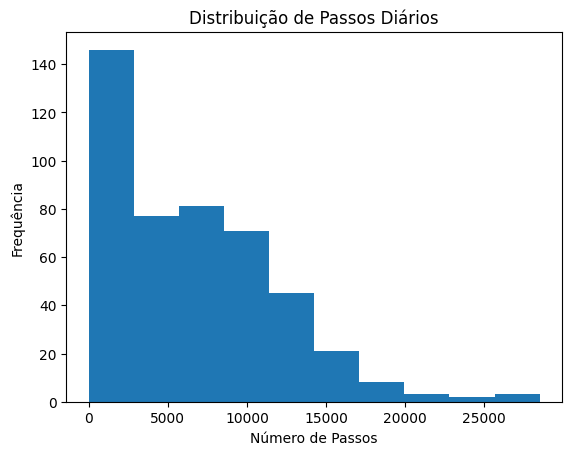

In [7]:
plt.figure()
plt.hist(df['TotalSteps'])
plt.title('Distribuição de Passos Diários')
plt.xlabel('Número de Passos')
plt.ylabel('Frequência')
plt.show()

### Análise da Distribuição de Passos Diários

O gráfico apresenta a distribuição da variável `TotalSteps`, que representa o número total de passos dados pelos usuários em um dia.

No eixo horizontal (X) estão os valores de passos diários, enquanto o eixo vertical (Y) representa a frequência, ou seja, a quantidade de registros do dataset que se encontram em cada faixa de valores. Considerando que cada registro corresponde a um usuário em um determinado dia, essa frequência indica quantas vezes aquele padrão de comportamento ocorreu.

Observa-se que a maior concentração de valores está em faixas mais baixas de passos, indicando que grande parte dos usuários apresenta níveis reduzidos de atividade física. Por outro lado, há uma menor quantidade de registros com valores elevados, o que demonstra a existência de usuários mais ativos, porém em menor proporção.

A distribuição apresenta assimetria à direita, ou seja, há poucos registros com valores muito altos de passos em comparação com a maioria, que se concentra em níveis mais baixos ou moderados de atividade.

A variável `TotalSteps` foi escolhida para análise por ser um dos principais indicadores de atividade física diária, estando diretamente relacionada ao comportamento de saúde do usuário. No contexto do WellMe, essa variável é altamente relevante, pois permite identificar o nível de participação do usuário nas atividades propostas, sendo um forte indicativo de engajamento.

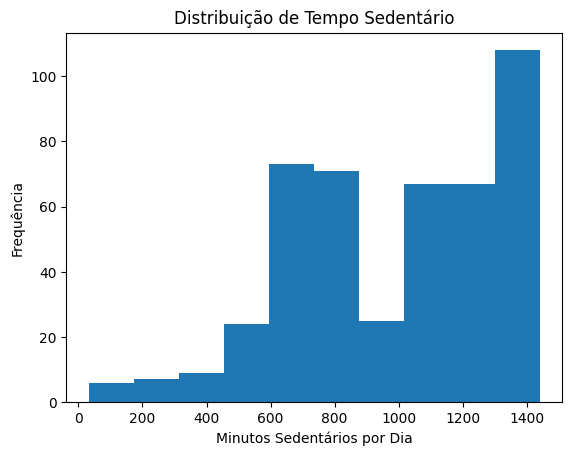

In [8]:
plt.figure()
plt.hist(df['SedentaryMinutes'])
plt.title('Distribuição de Tempo Sedentário')
plt.xlabel('Minutos Sedentários por Dia')
plt.ylabel('Frequência')
plt.show()

### Análise da Distribuição de Tempo Sedentário

O gráfico apresenta a distribuição da variável `SedentaryMinutes`, que representa o tempo, em minutos, que os usuários permanecem sedentários ao longo do dia.

No eixo horizontal (X) estão os valores de minutos sedentários por dia, enquanto o eixo vertical (Y) representa a frequência.

Observa-se uma alta concentração de valores em faixas elevadas de tempo sedentário, principalmente próximas de 1.000 a 1.400 minutos por dia. Isso indica que grande parte dos usuários passa uma quantidade significativa do tempo em atividades sedentárias.

Além disso, há uma menor presença de registros com baixos níveis de sedentarismo, o que reforça o padrão de comportamento mais inativo predominante no dataset.

A variável `SedentaryMinutes` foi escolhida por representar o comportamento oposto à atividade física, sendo um indicador importante do nível de inatividade dos usuários. No contexto do WellMe, essa variável é altamente relevante, pois usuários com alto tempo sedentário tendem a apresentar menor engajamento com hábitos saudáveis.

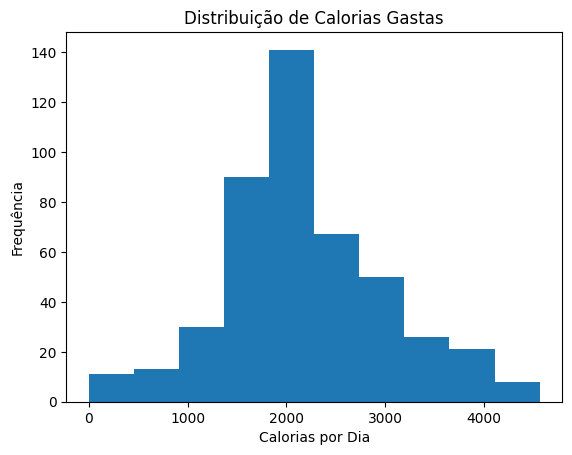

In [11]:
plt.figure()
plt.hist(df['Calories'])
plt.title('Distribuição de Calorias Gastas')
plt.xlabel('Calorias por Dia')
plt.ylabel('Frequência')
plt.show()

### Análise da Distribuição de Calorias Gastas

O gráfico apresenta a distribuição da variável `Calories`, que representa a quantidade de calorias gastas pelos usuários ao longo do dia.

No eixo horizontal (X) estão os valores de calorias diárias, enquanto o eixo vertical (Y) representa a frequência.

Observa-se uma concentração maior de valores entre aproximadamente 1.500 e 2.500 calorias, indicando que a maioria dos usuários apresenta um nível moderado de gasto energético diário.

Também é possível identificar a presença de valores mais extremos, tanto baixos quanto altos, o que demonstra a existência de diferentes perfis de usuários, desde aqueles com pouca atividade até usuários com maior nível de esforço físico.

A distribuição apresenta leve assimetria à direita, com alguns registros de alto gasto calórico, o que pode estar relacionado a dias com maior nível de atividade física.

A variável `Calories` foi escolhida por representar o gasto energético do usuário, sendo um indicador complementar às variáveis de atividade física. No contexto do WellMe, essa variável é relevante, pois está diretamente associada ao nível de esforço e participação do usuário nas atividades do aplicativo.

Dessa forma, a análise de `Calories`, em conjunto com variáveis como `TotalSteps` e `SedentaryMinutes`, permite uma compreensão mais completa do comportamento dos usuários, contribuindo para a construção da variável de engajamento e para o desenvolvimento do modelo de previsão.

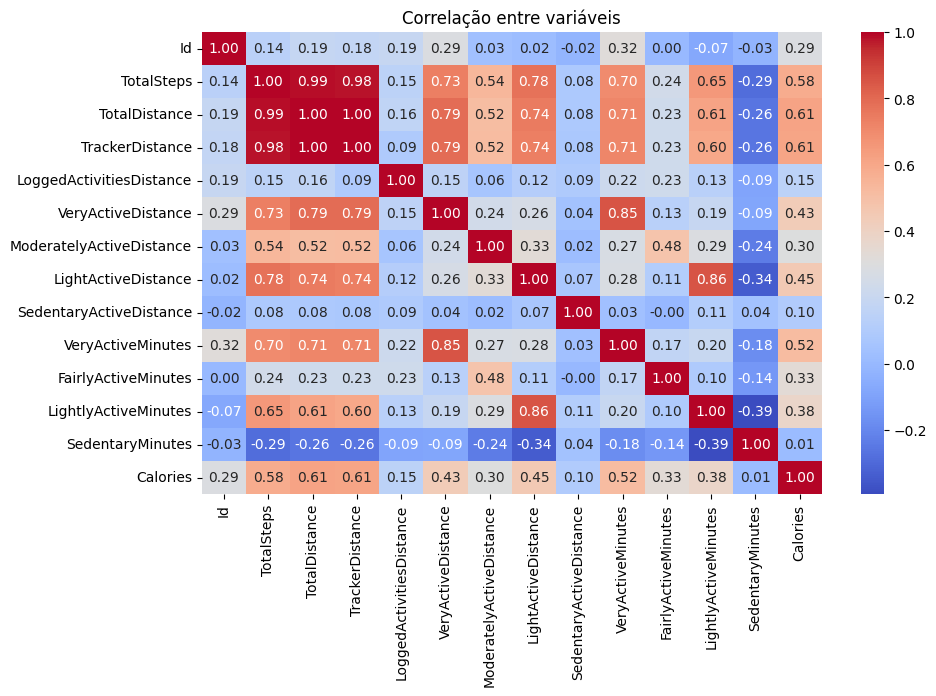

In [10]:
import seaborn as sns

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlação entre variáveis')
plt.show()

### Análise de Correlação entre Variáveis

A matriz de correlação permite identificar o grau de relação linear entre as variáveis numéricas do dataset, com valores variando de -1 (correlação negativa forte) até 1 (correlação positiva forte).

Observa-se uma correlação extremamente alta entre `TotalSteps`, `TotalDistance` e `TrackerDistance`, com valores próximos de 1. Esse resultado indica que essas variáveis carregam praticamente a mesma informação, o que é esperado, uma vez que o aumento no número de passos está diretamente relacionado ao aumento da distância percorrida. Nesse contexto, essas variáveis são redundantes, e a utilização de todas no modelo pode gerar excesso de informação sem ganho real de desempenho.

Além disso, variáveis relacionadas à atividade física, como `VeryActiveMinutes`, `LightlyActiveMinutes` e `VeryActiveDistance`, apresentam correlação positiva com `TotalSteps`, o que reforça a consistência dos dados, já que usuários mais ativos tendem a registrar maior movimentação ao longo do dia.

Por outro lado, a variável `SedentaryMinutes` apresenta correlação negativa com variáveis de atividade, como `TotalSteps` e `LightlyActiveMinutes`. Esse comportamento é coerente, pois o aumento do tempo sedentário está associado à redução da atividade física, evidenciando uma relação inversa entre esses comportamentos.

A variável `Calories` apresenta correlação moderada com variáveis de atividade, indicando que o gasto calórico está relacionado ao nível de movimento do usuário, mas também pode ser influenciado por outros fatores, como metabolismo individual e características fisiológicas.

De forma geral, as correlações observadas são consistentes com o comportamento esperado dos usuários, o que reforça a qualidade e coerência do dataset. No entanto, a presença de alta correlação entre algumas variáveis indica a necessidade de seleção de features nas próximas etapas, evitando redundância e possíveis impactos negativos no desempenho do modelo.

Essa análise é fundamental para o projeto WellMe, pois orienta a escolha das variáveis mais relevantes para representar o comportamento dos usuários, contribuindo diretamente para a construção de um modelo mais eficiente na previsão do nível de engajamento.